# Conformal Change Detection with AT and COAT

If you are working with this notebook in a Google Colab environment, change the runtime to GPU.

In [ ]:
%pip install git+https://github.com/lightning-uq-box/lightning-uq-box.git
%pip install "torchgeo>=0.10" "segmentation-models-pytorch>=0.5" "timm>=1.0.28"

## Per-image recall control for binary change masks

A binary change detection model outputs a probability map $\hat p_i \in [0,1]^{H \times W}$
for each image pair $x_i$, and a mask is obtained by keeping every pixel with
$\hat p_{ij} \ge \tau$. The common choice $\tau = 0.5$ comes with no statement about how
many of the changed pixels end up in the mask. In settings where a missed change is more
costly than a false alarm, for example when the mask is used to select buildings for inspection,
one would rather state a target such as "on average, at least 90% of the changed pixels of
an image are in its mask" and choose the threshold so that the target holds on new images.

This notebook follows the formulation of
[Luo et al. (2026)](https://openreview.net/forum?id=Gd2AiWes1J). For image $i$ with the set
of changed pixels $Y_i$, the per-image recall at threshold $\tau$ is

$$r_i(\tau) = \frac{|\{j \in Y_i : \hat p_{ij} \ge \tau\}|}{|Y_i|},$$

the fraction of changed pixels whose probability is at least $\tau$. An image without any
changed pixel has $r_i = 1$ by convention. The false-negative rate of image $i$ is
$1 - r_i$, and the target for a new test image $n+1$ is

$$\mathbb{E}\left[r_{n+1}(\tau_{n+1})\right] \ge 1 - \alpha,$$

where $\alpha$ is the tolerated false-negative rate and the expectation is taken over the
calibration images and the test image. We call the mean per-image recall on a test set
its coverage.

The three methods compared here differ in how $\tau$ depends on the image:

- **Conformal risk control (CRC)** [(Angelopoulos et al., 2024)](https://arxiv.org/abs/2208.02814)
  uses one global threshold, the largest $\tau$ for which the mean recall on $n$ calibration
  images reaches $\frac{n+1}{n}(1-\alpha)$. The factor $\frac{n+1}{n}$ is the finite-sample
  correction under which the calibration mean bounds the test expectation.
- **Adaptive thresholding (AT)** trains a threshold network $g_\theta(x_i, \hat p_i)$, a
  ResNet-50 that receives the image pair and the probability map and outputs one threshold
  per image. Its training target is the oracle threshold
  $\tau_i^\star = \max\{\tau : r_i(\tau) \ge 1-\alpha\}$ of each training image, and the loss
  is the mean squared error to $\tau_i^\star$.
- **COAT** trains the same network without oracle thresholds. It replaces the hard mask by
  $\sigma((\hat p_{ij} - \tau)/T)$ with temperature $T$, which makes the recall differentiable:

$$\tilde r_i(\tau) = \frac{1}{|Y_i| + \epsilon} \sum_{j \in Y_i} \sigma\left(\frac{\hat p_{ij} - \tau}{T}\right),
\qquad \mathcal{L}(\theta) = \frac{1}{B} \sum_{i=1}^{B} \left(\tilde r_i(g_\theta(x_i, \hat p_i)) - (1-\alpha)\right)^2 .$$

Here $\sigma$ is the logistic function, $\epsilon = 10^{-6}$ keeps the ratio finite for images
without change, and $B$ is the batch size. The loss is small only when every image in the batch has
soft recall close to $1-\alpha$, not already when the batch mean is.

Neither network output comes with a guarantee by itself. Therefore, AT and COAT share a
calibration step on held-out images: with the network fixed, the predicted thresholds
$\hat\tau_i$ are shifted by a single scalar $t'$,

$$\tau_i = \mathrm{clip}(\hat\tau_i - t', 0, 1),$$

and $t'$ is the smallest shift for which the calibration images reach mean recall
$\frac{n+1}{n}(1-\alpha)$. This is the same risk-control argument as in CRC, applied to the
family of per-image thresholds indexed by $t'$. The guarantee is marginal: it holds for the
mean recall over test images, assuming calibration and test images are exchangeable. It
does not bound the recall of an individual image, and it says nothing about false
positives. The quantity that the per-image methods aim to reduce is the coverage gap
$\frac{1}{m}\sum_{i=1}^{m} |r_i(\tau_i) - (1-\alpha)|$ over $m$ test images, the mean
distance of each image's recall from the target.

## Imports

In [2]:
import json
import logging
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import segmentation_models_pytorch as smp
import torch
from huggingface_hub import hf_hub_download
from lightning import Trainer, seed_everything
from lightning.pytorch.loggers import CSVLogger
from matplotlib.patches import Patch
from safetensors.torch import load_file
from torch import Tensor, nn
from torch.utils.data import DataLoader, Dataset
from torchgeo.datasets import LEVIRCDPlus

from lightning_uq_box.models import ThresholdPredictor
from lightning_uq_box.uq_methods import (
    COAT,
    AdaptiveThresholding,
    DeterministicSegmentation,
)

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", module="lightning")
seed_everything(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HF_REPO = "lightning-uq-box/levircd_coat"
DATA_ROOT = "data"


def fetch(filename: str) -> str:
    """Download one file of the tutorial's model repository and return its local path."""
    return hf_hub_download(HF_REPO, filename)

[rank: 0] Seed set to 0


## LEVIR-CD+ dataset

LEVIR-CD+ [(Shen et al., 2021)](https://arxiv.org/abs/2107.09244) contains 985 pairs of
1024 × 1024 RGB images at 0.5 m resolution from urban areas in Texas, taken between 2002 and
2020. Each pair has a binary mask of building change, and the dataset comes with an official
split into 637 training and 348 test pairs. We use one 512 × 512 crop per pair: a random
crop with flips while training the base model and the threshold networks, and the center
crop for calibration and testing, so that one image pair is one calibration or test unit.

Files already downloaded and verified
Files already downloaded and verified


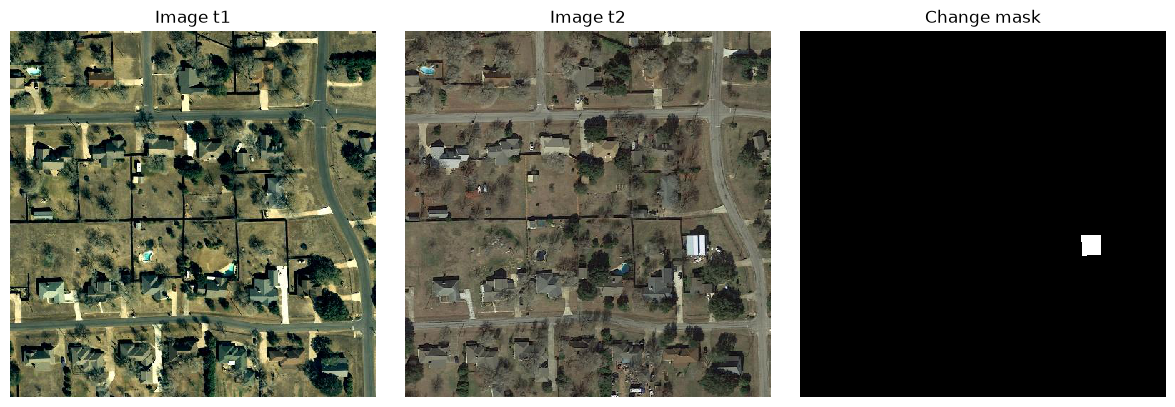

In [3]:
datasets = {
    split: LEVIRCDPlus(DATA_ROOT, split=split, download=True, checksum=False)
    for split in ("train", "test")
}
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406] * 2).view(6, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225] * 2).view(6, 1, 1)


class ChangePairs(Dataset):
    """LEVIR-CD+ pairs, selected by file name and stacked into six channels."""

    def __init__(self, names: list[str], train: bool = False, size: int = 512) -> None:
        """Index the named pairs; ``train`` enables random crops and flips."""
        self.lookup = {
            os.path.basename(files["image1"]): (dataset, index)
            for dataset in datasets.values()
            for index, files in enumerate(dataset.files)
        }
        self.names, self.train, self.size = names, train, size

    def __len__(self) -> int:
        """Return the number of image pairs."""
        return len(self.names)

    def raw(self, index: int) -> tuple[Tensor, Tensor]:
        """Return the cropped pair [6,size,size] in [0,1] and its mask [1,size,size]."""
        dataset, position = self.lookup[self.names[index]]
        sample = dataset[position]
        image, mask = sample["image"].flatten(0, 1) / 255, sample["mask"].float()
        height, width = mask.shape[-2:]
        if self.train:
            top = int(torch.randint(0, height - self.size + 1, ()))
            left = int(torch.randint(0, width - self.size + 1, ()))
        else:
            top, left = (height - self.size) // 2, (width - self.size) // 2
        window = (..., slice(top, top + self.size), slice(left, left + self.size))
        image, mask = image[window], mask[window]
        if self.train:
            if torch.rand(()) < 0.5:
                image, mask = image.flip(-1), mask.flip(-1)
            if torch.rand(()) < 0.5:
                image, mask = image.flip(-2), mask.flip(-2)
        return image, mask

    def __getitem__(self, index: int) -> dict:
        """Return the normalized pair as ``input`` and the change mask as ``target``."""
        image, mask = self.raw(index)
        return {
            "input": (image - IMAGENET_MEAN) / IMAGENET_STD,
            "target": mask,
            "filename": self.names[index],
        }


def show_pair(axes, image: Tensor, mask: Tensor) -> None:
    """Plot both acquisitions and the change mask of one pair."""
    for ax, panel, title in zip(
        axes,
        (image[:3].permute(1, 2, 0), image[3:].permute(1, 2, 0), mask[0]),
        ("Image t1", "Image t2", "Change mask"),
        strict=True,
    ):
        ax.imshow(panel, cmap="gray" if panel.ndim == 2 else None, interpolation="none")
        ax.set_title(title)
        ax.axis("off")


train_names = [os.path.basename(f["image1"]) for f in datasets["train"].files]
test_names = [os.path.basename(f["image1"]) for f in datasets["test"].files]
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
show_pair(axes, *ChangePairs(train_names).raw(1))
fig.tight_layout()
plt.show()

## Four disjoint splits

The base model, the threshold networks, the calibration shift and the evaluation each
need their own images: a threshold network trained on images that the base model was
trained on would see overconfident probability maps, and a calibration shift computed on
the test images would make the test coverage meaningless. We therefore use four disjoint
sets. The base model is trained on 437 pairs of the official training split ($D_1$), and
the threshold networks on another 100 training pairs ($D_2$). The remaining 100 training
pairs are not used. The calibration set $D_\mathrm{cal}$ (100 pairs) and the test set
$D_\mathrm{test}$ (248 pairs) are both drawn from the official test split, so that
calibration and test images come from the same population, which the exchangeability
assumption of the guarantee requires. The cell below draws the splits from fixed seeds and
checks that they match the splits used to train the published weights.

In [4]:
order = np.random.default_rng(42).permutation(train_names).tolist()
test_order = np.random.default_rng(1000).permutation(test_names).tolist()
splits = {
    "D1 (base model)": order[200:],
    "D2 (threshold network)": order[100:200],
    "Dcal (calibration)": test_order[:100],
    "Dtest (evaluation)": test_order[100:],
}
names = list(splits.values())
assert sum(map(len, names)) == len(set().union(*names)), "splits overlap"

with open(fetch("splits.json")) as stream:
    published = json.load(stream)
for key, (_, value) in zip(
    ["base_train", "threshold_train", "calibration", "test"],
    splits.items(),
    strict=True,
):
    assert published[key] == value, key


def change_fraction(names: list[str]) -> tuple[float, float]:
    """Return the changed-pixel fraction and the share of crops without change."""
    masks = torch.stack([ChangePairs(names).raw(i)[1] for i in range(len(names))])
    return masks.mean().item(), (masks.flatten(1).sum(1) == 0).float().mean().item()


pd.DataFrame(
    [
        {"split": key, "pairs": len(value)}
        | dict(zip(["changed pixels", "crops without change"], change_fraction(value)))
        for key, value in splits.items()
    ]
).round(3)

,split,pairs,changed pixels,crops without change
0,D1 (base model),437,0.045,0.327
1,D2 (threshold network),100,0.049,0.300
2,Dcal (calibration),100,0.045,0.400
3,Dtest (evaluation),248,0.039,0.298


In $D_\mathrm{test}$, 30% of the crops contain no changed pixel. These images have recall
one for every threshold, so they count as covered regardless of the method. For this
reason we also report the coverage over the crops that do contain change.

## Base model: siamese U-Net over a frozen DINOv3 ConvNeXt-B

The base model applies one encoder to each acquisition separately and compares the two
feature pyramids level by level before a U-Net decoder, following the siamese design of
[Chen & Shi (2020)](https://www.mdpi.com/2072-4292/12/10/1662). The encoder is the
ConvNeXt-B distilled from DINOv3 [(Siméoni et al., 2025)](https://arxiv.org/abs/2508.10104)
and is kept frozen, so only the fusion layers, the decoder and the segmentation head are
trained (7.9 million of 95.4 million parameters). These encoder weights were pretrained on
web images (LVD-1689M), not on satellite imagery, and are distributed under the
[DINOv3 License](https://huggingface.co/timm/convnext_base.dinov3_lvd1689m); by
downloading them you accept its terms. The trained decoder weights are downloaded from
the Hugging Face Hub, and the encoder weights are downloaded from their original source.

In [5]:
class SiameseChangeUNet(nn.Module):
    """Siamese U-Net: a shared frozen encoder per acquisition, fused by feature difference."""

    def __init__(self, encoder_name: str = "tu-convnext_base.dinov3_lvd1689m") -> None:
        """Build the encoder, decoder and one fusion block per feature level."""
        super().__init__()
        # For timm ("tu-") encoders, any weights name loads the tag's pretrained weights.
        unet = smp.Unet(encoder_name, encoder_weights="imagenet", classes=1)
        self.encoder = unet.encoder.requires_grad_(False).eval()
        self.decoder, self.segmentation_head = unet.decoder, unet.segmentation_head
        # ConvNeXt has no stride-2 feature map; that level has zero channels.
        self.fuse = nn.ModuleList(
            nn.Identity()
            if channels == 0
            else nn.Sequential(
                nn.Conv2d(2 * channels, channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(channels),
                nn.ReLU(inplace=True),
            )
            for channels in self.encoder.out_channels
        )

    def train(self, mode: bool = True) -> "SiameseChangeUNet":
        """Keep the frozen encoder in evaluation mode."""
        super().train(mode)
        self.encoder.eval()
        return self

    def forward(self, x: Tensor) -> Tensor:
        """Map a stacked pair [B,6,H,W] to change logits [B,1,H,W]."""
        with torch.no_grad():
            first, second = self.encoder(x[:, :3]), self.encoder(x[:, 3:])
        fused = [
            block(torch.cat((a - b, (a - b).abs()), dim=1))
            for block, a, b in zip(self.fuse, first, second, strict=True)
        ]
        return self.segmentation_head(self.decoder(fused))


base_model = SiameseChangeUNet()
trainable = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"{trainable:,} trainable of {sum(p.numel() for p in base_model.parameters()):,}")

7,876,201 trainable of 95,440,617


We trained the base model for 200 epochs on $D_1$ with binary cross-entropy, Adam with
learning rate $10^{-3}$ and batch size 24, holding the learning rate for 100 epochs and
then decaying it linearly to zero. The learning rate was chosen from
$\{10^{-4}, 3\cdot10^{-4}, 10^{-3}, 3\cdot10^{-3}\}$ by the F1 score on $D_2$ after the final
epoch, before any calibration or test image was used. With `USE_CHECKPOINT = True` the
trained weights are downloaded; set it to `False` to train the base model and both threshold
networks yourself, which takes several GPU hours.

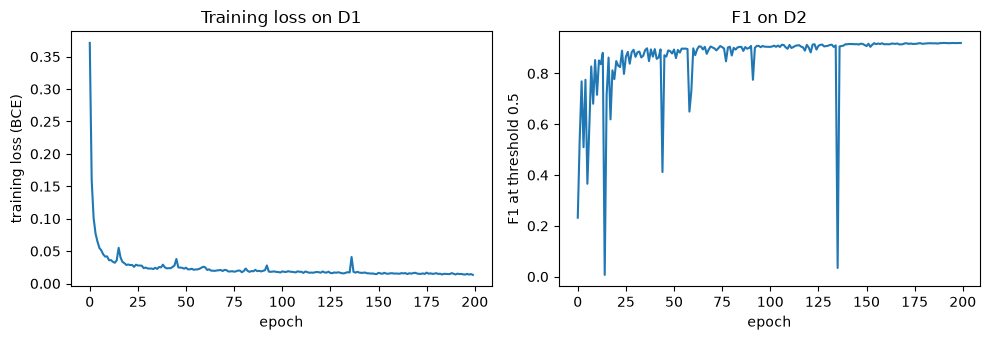

In [6]:
USE_CHECKPOINT = True
base_dir = "base_training"


def loader(names: list[str], batch_size: int = 16, train: bool = False) -> DataLoader:
    """Build a data loader; only training loaders shuffle and augment."""
    return DataLoader(
        ChangePairs(names, train=train),
        batch_size=batch_size,
        shuffle=train,
        num_workers=4,
        drop_last=train,
    )


def linear_decay(optimizer, epochs: int = 200, hold: int = 100):
    """Hold the learning rate, then decay it linearly to zero."""
    return torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda epoch: min(1.0, max(0.0, (epochs - epoch) / (epochs - hold)))
    )


if USE_CHECKPOINT:
    state = load_file(fetch("base_trainable.safetensors"))
    missing, unexpected = base_model.load_state_dict(state, strict=False)
    assert not unexpected and all(key.startswith("encoder.") for key in missing)
    base_log = pd.read_csv(fetch("logs/base_lr1e-3_metrics.csv"))
else:
    seed_everything(42)
    task = DeterministicSegmentation(
        base_model,
        nn.BCEWithLogitsLoss(),
        task="binary",
        optimizer=lambda params: torch.optim.Adam(
            [p for p in params if p.requires_grad], lr=1e-3, betas=(0.5, 0.99)
        ),
        lr_scheduler=linear_decay,
    )
    Trainer(max_epochs=200, logger=CSVLogger(base_dir), enable_checkpointing=False).fit(
        task,
        train_dataloaders=loader(splits["D1 (base model)"], 24, train=True),
        val_dataloaders=loader(splits["D2 (threshold network)"]),
    )
    base_log = pd.read_csv(f"{base_dir}/lightning_logs/version_0/metrics.csv")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
base_log.groupby("epoch")["train_loss"].mean().plot(ax=axes[0])
base_log.dropna(subset=["valF1Score"]).plot(
    "epoch", "valF1Score", ax=axes[1], legend=False
)
axes[0].set(xlabel="epoch", ylabel="training loss (BCE)", title="Training loss on D1")
axes[1].set(xlabel="epoch", ylabel="F1 at threshold 0.5", title="F1 on D2")
fig.tight_layout()
plt.show()

The F1 score on $D_2$ drops sharply in a few single epochs, to 0.007 at epoch 14 and to 0.03 at
epoch 135, and recovers in the following epoch. After the final epoch, which is the checkpoint
used here, it is 0.920.

Next we compute the probability maps of the frozen base model once for $D_\mathrm{cal}$
and $D_\mathrm{test}$. All methods below reuse them, since none of the methods changes
the base model.

In [7]:
@torch.no_grad()
def probabilities(names: list[str]) -> tuple[Tensor, Tensor]:
    """Return base-model probabilities and binary masks, both [N,1,512,512], on the CPU."""
    base_model.to(device).eval()
    prob, target = [], []
    for batch in loader(names):
        prob.append(base_model(batch["input"].to(device)).sigmoid().cpu())
        target.append(batch["target"].bool())
    return torch.cat(prob), torch.cat(target)


cal_prob, cal_target = probabilities(splits["Dcal (calibration)"])
test_prob, test_target = probabilities(splits["Dtest (evaluation)"])


def recall(prob: Tensor, target: Tensor, tau: Tensor | float) -> Tensor:
    """Per-image recall of the mask prob >= tau; images without change count as one."""
    tau = torch.as_tensor(tau, dtype=prob.dtype).expand(len(prob)).view(-1, 1, 1, 1)
    hits = ((prob >= tau) & target).flatten(1).sum(1)
    positives = target.flatten(1).sum(1)
    return torch.where(positives > 0, hits / positives.clamp(min=1), 1.0)


def evaluate(prob: Tensor, target: Tensor, tau: Tensor | float, alpha: float) -> dict:
    """Coverage, coverage gap and mask quality of one threshold rule on one split."""
    tau = torch.as_tensor(tau, dtype=prob.dtype).expand(len(prob))
    pred = prob >= tau.view(-1, 1, 1, 1)
    r = recall(prob, target, tau)
    changed = target.flatten(1).any(1)
    tp = (pred & target).sum()
    return {
        "coverage": r.mean().item(),
        "coverage (crops with change)": r[changed].mean().item(),
        "coverage gap": (r - (1 - alpha)).abs().mean().item(),
        "F1": (2 * tp / (pred.sum() + target.sum())).item(),
        "IoU": (tp / (pred | target).sum()).item(),
        "predicted foreground": pred.float().mean().item(),
        "tau = 0": (tau <= 0).float().mean().item(),
    }


print(f"true foreground fraction on Dtest: {test_target.float().mean():.4f}")
pd.DataFrame(
    {"base model, threshold 0.5": evaluate(test_prob, test_target, 0.5, alpha=0.1)}
).T.round(4)

true foreground fraction on Dtest: 0.0395


,coverage,coverage (crops with change),coverage gap,F1,IoU,predicted foreground,tau = 0
"base model, threshold 0.5",0.7845,0.6928,0.1869,0.8392,0.723,0.0375,0.0


## AT and COAT threshold networks

Both threshold networks receive the six-channel image pair together with the probability
map; the first layer takes its number of input channels from the first batch. Each method is fitted in two
stages with separate `Trainer` objects: the first trains the threshold network on $D_2$
(AT for 30 epochs with learning rate $10^{-4}$ and batch size 24, COAT for 60 epochs with
learning rate $5\cdot10^{-4}$, batch size 64 and $T = 0.05$), and the second, with
`max_epochs=1`, computes the shift $t'$ on $D_\mathrm{cal}$. We fit one network per method
and per $\alpha \in \{0.1, 0.2\}$. With `USE_CHECKPOINT = True` the first stage is replaced by
downloading the trained networks, and the calibration is computed here.

In [8]:
ALPHAS = (0.1, 0.2)
METHODS = {"AT": AdaptiveThresholding, "COAT": COAT}
QUIET = {
    "devices": 1,
    "logger": False,
    "enable_checkpointing": False,
    "enable_progress_bar": False,
    "enable_model_summary": False,
}
SETTINGS = {
    "AT": {"epochs": 30, "batch_size": 24},
    "COAT": {"epochs": 60, "batch_size": 64},
}


def fit_threshold_method(name: str, alpha: float):
    """Train (or download) one threshold network, then calibrate it on Dcal."""
    cls = METHODS[name]
    if USE_CHECKPOINT:
        # The downloaded checkpoints omit the frozen encoder, which base_model provides.
        warnings.filterwarnings("ignore", "Found keys that are in the model state dict")
        method = cls.load_from_checkpoint(
            fetch(f"threshold/{name.lower()}_alpha{alpha}.ckpt"),
            model=base_model,
            threshold_model=ThresholdPredictor(pretrained=False),
            strict=False,
            map_location="cpu",
        )
    else:
        seed_everything(2000)
        method = cls(model=base_model, alpha=alpha)
        Trainer(max_epochs=SETTINGS[name]["epochs"], **QUIET).fit(
            method,
            train_dataloaders=loader(
                splits["D2 (threshold network)"],
                SETTINGS[name]["batch_size"],
                train=True,
            ),
        )
    Trainer(max_epochs=1, **QUIET).fit(
        method, train_dataloaders=loader(splits["Dcal (calibration)"])
    )
    return method.to(device).eval()


methods = {
    (name, alpha): fit_threshold_method(name, alpha)
    for name in METHODS
    for alpha in ALPHAS
}
pd.Series(
    {f"{name}, alpha={alpha}": m.t_prime.item() for (name, alpha), m in methods.items()}
)

AT, alpha=0.1      0.614685
AT, alpha=0.2      0.281067
COAT, alpha=0.1   -0.011047
COAT, alpha=0.2   -0.099548
dtype: float64

The table lists the calibrated shift $t'$ of each network. A positive shift lowers all
predicted thresholds, which adds pixels to every mask, and a negative shift raises them.
To evaluate a calibrated method we reuse the stored probability maps and only run the
threshold network, through the same `adjust_model_logits` call that the method's
`forward` uses.

In [9]:
@torch.no_grad()
def thresholds(method, names: list[str], prob: Tensor) -> Tensor:
    """Calibrated per-image thresholds [N] of one method, given stored probabilities."""
    taus, start = [], 0
    for batch in loader(names):
        X = batch["input"].to(device)
        phat = prob[start : start + len(X)].to(device)
        start += len(X)
        out = method.adjust_model_logits((phat, method.threshold_model(X, phat)))
        taus.append(out["tau"].cpu())
    return torch.cat(taus)


test_tau = {
    key: thresholds(method, splits["Dtest (evaluation)"], test_prob)
    for key, method in methods.items()
}

## CRC baseline with one global threshold

CRC needs no training. On $D_\mathrm{cal}$ it searches for the largest threshold whose mean
recall still reaches the corrected target $\frac{n+1}{n}(1-\alpha)$. Since the mean recall
can only decrease as the threshold increases, a bisection finds it.

In [10]:
def crc_threshold(prob: Tensor, target: Tensor, alpha: float) -> float:
    """Largest global threshold with calibration mean recall >= (n+1)/n (1-alpha)."""
    n = len(prob)
    level = (n + 1) / n * (1 - alpha)
    if level > 1:
        return 0.0
    low, high = 0.0, 1.0
    if recall(prob, target, high).mean() >= level:
        return high
    while high - low > 1e-6:
        mid = (low + high) / 2
        if recall(prob, target, mid).mean() >= level:
            low = mid
        else:
            high = mid
    return low


crc_tau = {alpha: crc_threshold(cal_prob, cal_target, alpha) for alpha in ALPHAS}
crc_tau

{0.1: 0.03742027282714844, 0.2: 0.5811166763305664}

## Coverage and mask quality on the test set

The table reports, for each $\alpha$, the base model, CRC, AT and COAT on the 248 test pairs. The
rows labelled "base model" are the uncalibrated base model with the usual threshold 0.5, which
does not depend on $\alpha$ and is repeated for comparison. The columns are the coverage (mean per-image recall), the coverage restricted to
crops that contain change, the coverage gap, the pixel-level F1 score and IoU of the change
class, the fraction of pixels predicted as change, and the fraction of images whose
threshold was clipped to zero, which marks every pixel of that image as change.

In [11]:
rules = {}
for alpha in ALPHAS:
    rules[("base model", alpha)] = 0.5
    rules[("CRC", alpha)] = crc_tau[alpha]
    for name in METHODS:
        rules[(name, alpha)] = test_tau[(name, alpha)]
results = pd.DataFrame(
    {
        (alpha, name): evaluate(test_prob, test_target, tau, alpha)
        for (name, alpha), tau in rules.items()
    }
).T
results.index.names = ["alpha", "method"]
results.round(3)

coverage  coverage (crops with change)  coverage gap     F1  \
alpha method                                                                    
0.1   base model     0.784                         0.693         0.187  0.839   
      CRC            0.880                         0.828         0.156  0.781   
      AT             0.921                         0.887         0.128  0.208   
      COAT           0.883                         0.833         0.145  0.775   
0.2   base model     0.784                         0.693         0.213  0.839   
      CRC            0.771                         0.674         0.211  0.836   
      AT             0.772                         0.675         0.209  0.831   
      COAT           0.792                         0.703         0.212  0.796   

                    IoU  predicted foreground  tau = 0  
alpha method                                            
0.1   base model  0.723                 0.037    0.000  
      CRC         0.640                 0.054    0.000  
      AT          0.116                 0.317    0.282  
      COAT        0.633                 0.051    0.000  
0.2   base model  0.723                 0.037    0.000  
      CRC         0.719                 0.036    0.000  
      AT          0.710                 0.036    0.000  
      COAT        0.661                 0.035    0.000

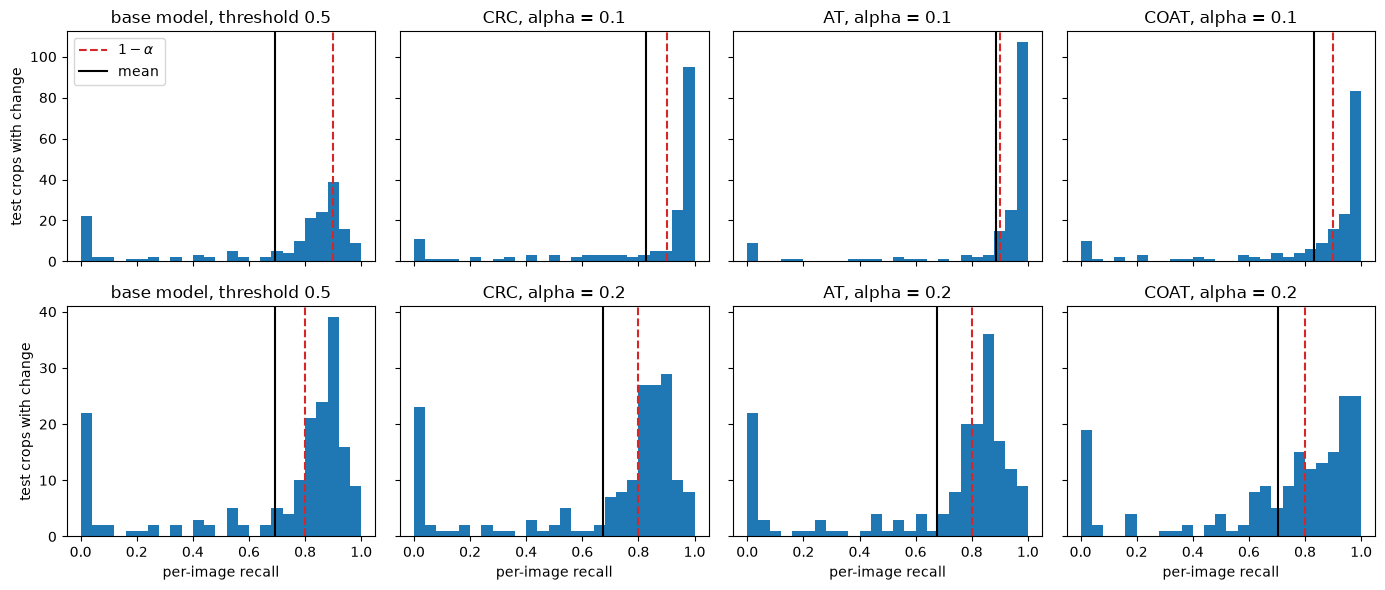

In [12]:
def panel_title(name: str, alpha: float) -> str:
    """Name a threshold rule; the base model's threshold 0.5 does not depend on alpha."""
    return (
        "base model, threshold 0.5"
        if name == "base model"
        else f"{name}, alpha = {alpha}"
    )


changed = test_target.flatten(1).any(1)
fig, axes = plt.subplots(len(ALPHAS), 4, figsize=(14, 6), sharex=True, sharey="row")
for row, alpha in enumerate(ALPHAS):
    for col, name in enumerate(["base model", "CRC", "AT", "COAT"]):
        r = recall(test_prob, test_target, rules[(name, alpha)])[changed]
        ax = axes[row, col]
        ax.hist(r.numpy(), bins=np.linspace(0, 1, 26), color="tab:blue")
        ax.axvline(1 - alpha, color="tab:red", linestyle="--", label=r"$1-\alpha$")
        ax.axvline(r.mean().item(), color="black", label="mean")
        ax.set_title(panel_title(name, alpha))
        if row == len(ALPHAS) - 1:
            ax.set_xlabel("per-image recall")
    axes[row, 0].set_ylabel("test crops with change")
axes[0, 0].legend()
fig.tight_layout()
plt.show()

On this draw, the base model with threshold 0.5 reaches a coverage of 0.784, below the target of 0.9 for
$\alpha = 0.1$ and also below 0.8 for $\alpha = 0.2$. For $\alpha = 0.1$, the calibrated methods
reach a test coverage of 0.880 (CRC), 0.921 (AT) and 0.883 (COAT). The guarantee concerns the
expectation over calibration draws, so a single draw can fall below $1-\alpha$, as CRC and COAT
do here by about 0.02. The methods differ more in their masks than in their coverage. CRC lowers
the global threshold from 0.5 to 0.037, which increases the fraction of pixels predicted as change
from 0.037 to 0.054 and gives F1 0.781, and COAT reaches a similar F1 of 0.775. In contrast, AT sets the
threshold of 28% of the test images to zero, so these images are predicted as entirely changed,
which increases the predicted foreground to 0.317 and reduces F1 to 0.208. For $\alpha = 0.2$,
the CRC threshold of 0.581 lies above 0.5, the coverage of the calibrated methods lies between
0.771 and 0.792, and F1 lies between 0.796 and 0.836.

The coverage gaps of the calibrated methods lie between 0.128 and 0.156 for $\alpha = 0.1$ and
between 0.209 and 0.212 for $\alpha = 0.2$. Two groups of images account for most of the gap. The 30% of
crops without change have recall one, so each of them is at distance $\alpha$ from the target. Among the crops
with change, 9 to 23 fall into the lowest histogram bin (recall below 0.04) under every
calibrated method, and each of them is at a distance close to $1-\alpha$.

## Recall and precision of one global threshold

The table shows that for $\alpha = 0.1$ the calibrated masks have a lower F1 score than
the base model with threshold 0.5. The plot below shows the reason for a single global threshold on the test set:
the coverage (mean per-image recall), the recall pooled over all changed pixels, the precision
and the F1 score as functions of the threshold, with the CRC thresholds of both levels marked.

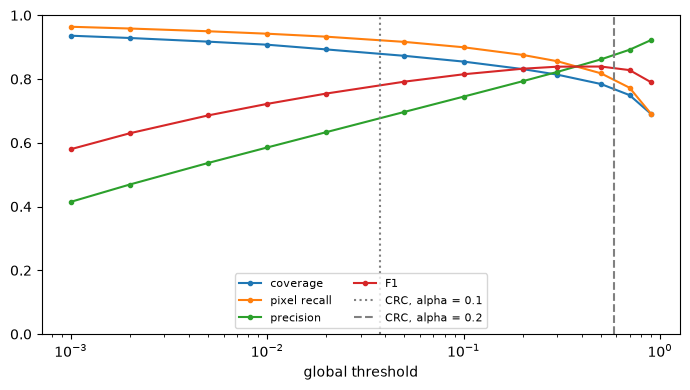

In [13]:
grid = [0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
curves = {key: [] for key in ["coverage", "pixel recall", "precision", "F1"]}
positives = test_target.sum()
for tau in grid:
    pred = test_prob >= tau
    tp = (pred & test_target).sum()
    curves["coverage"].append(recall(test_prob, test_target, tau).mean().item())
    curves["pixel recall"].append((tp / positives).item())
    curves["precision"].append((tp / pred.sum()).item())
    curves["F1"].append((2 * tp / (pred.sum() + positives)).item())
fig, ax = plt.subplots(figsize=(7, 4))
for label, values in curves.items():
    ax.plot(grid, values, marker="o", markersize=3, label=label)
for alpha, style in zip(ALPHAS, [":", "--"], strict=True):
    ax.axvline(
        crc_tau[alpha], color="gray", linestyle=style, label=f"CRC, alpha = {alpha}"
    )
ax.set(xscale="log", xlabel="global threshold", ylim=(0, 1))
ax.legend(fontsize=8, loc="lower center", ncol=2)
fig.tight_layout()
plt.show()

Lowering the global threshold from 0.5 to the CRC threshold of 0.037 for $\alpha = 0.1$ raises
the coverage from 0.784 to 0.880 and the pixel recall from 0.818 to 0.922. At the same time, the
precision falls from 0.862 to 0.676 and F1 from 0.839 to 0.780. F1 is highest for thresholds
between 0.3 and 0.5, so every global threshold that reaches the recall target of
$\alpha = 0.1$ has a lower F1 score than threshold 0.5. The coverage is below the pixel
recall at every threshold up to 0.7, because it averages over crops. Crops with little change count as much
as crops with dense change, and the base model misses a larger share of the changed pixels in
crops with little change, some of them with probabilities below 0.01.

## Per-image thresholds

The left panels show the calibrated threshold of each test image against the fraction of
its pixels that changed, with the CRC threshold as a horizontal line. Images without change
are drawn at a change fraction of $10^{-5}$ so that they remain visible on the logarithmic
axis.

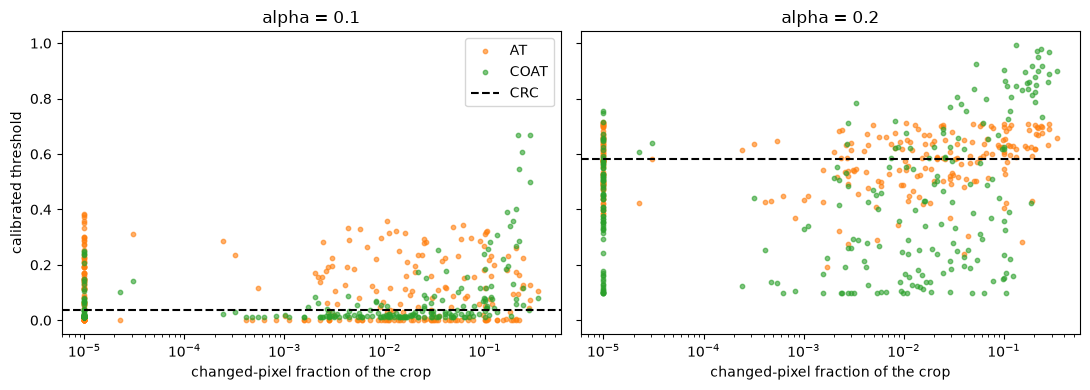

In [14]:
fraction = test_target.flatten(1).float().mean(1).clamp(min=1e-5)
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(11, 4), sharey=True)
for ax, alpha in zip(axes, ALPHAS, strict=True):
    for name, color in [("AT", "tab:orange"), ("COAT", "tab:green")]:
        ax.scatter(
            fraction, test_tau[(name, alpha)], s=10, alpha=0.6, label=name, c=color
        )
    ax.axhline(crc_tau[alpha], color="black", linestyle="--", label="CRC")
    ax.set(
        xscale="log",
        xlabel="changed-pixel fraction of the crop",
        title=f"alpha = {alpha}",
    )
axes[0].set_ylabel("calibrated threshold")
axes[0].legend()
fig.tight_layout()
plt.show()

For $\alpha = 0.1$, most COAT thresholds lie between 0 and 0.1, close to the CRC threshold. Among
the crops with change, thresholds above 0.2 occur mainly where the changed fraction exceeds 0.1. The AT thresholds
spread between 0 and about 0.35 without a visible relation to the changed fraction, and the
images at zero are those clipped by the calibration shift of 0.61. For $\alpha = 0.2$, the COAT
thresholds spread between 0.1 and 1.0 and increase with the changed fraction, while the AT
thresholds lie between about 0.2 and 0.75. Crops without change also receive a wide range of
thresholds. For these crops any threshold gives recall one, so a lower threshold only adds
false positives.

## Example test pairs

We look at four test pairs. Each is chosen by a rule applied to all test crops with change,
so that each row shows one of the effects discussed above:

- (a) the crop in which CRC at $\alpha = 0.1$ recovers the most changed pixels compared to
  the base model with threshold 0.5,
- (b) the crop in which the COAT threshold at $\alpha = 0.1$ lies furthest above the CRC
  threshold,
- (c) among the crops in which CRC at $\alpha = 0.2$ stays below a recall of 0.8, the crop in
  which COAT recovers the most changed pixels compared to CRC,
- (d) the crop with the most changed pixels among those that CRC at $\alpha = 0.1$ detects
  with a recall below 0.1.

These rows are selected to show the effects, so they are not typical crops; the tables and
histograms above describe the typical behavior. The masks are drawn as error maps, in which
white pixels are detected change, red pixels are missed change and blue pixels are false
alarms. The cell also counts, over all test crops with change, on how many crops only one of
COAT and CRC reaches the target recall $1-\alpha$.

alpha = 0.1: only COAT reaches 0.9 on 3 crops, only CRC on 12 crops
alpha = 0.2: only COAT reaches 0.8 on 12 crops, only CRC on 23 crops


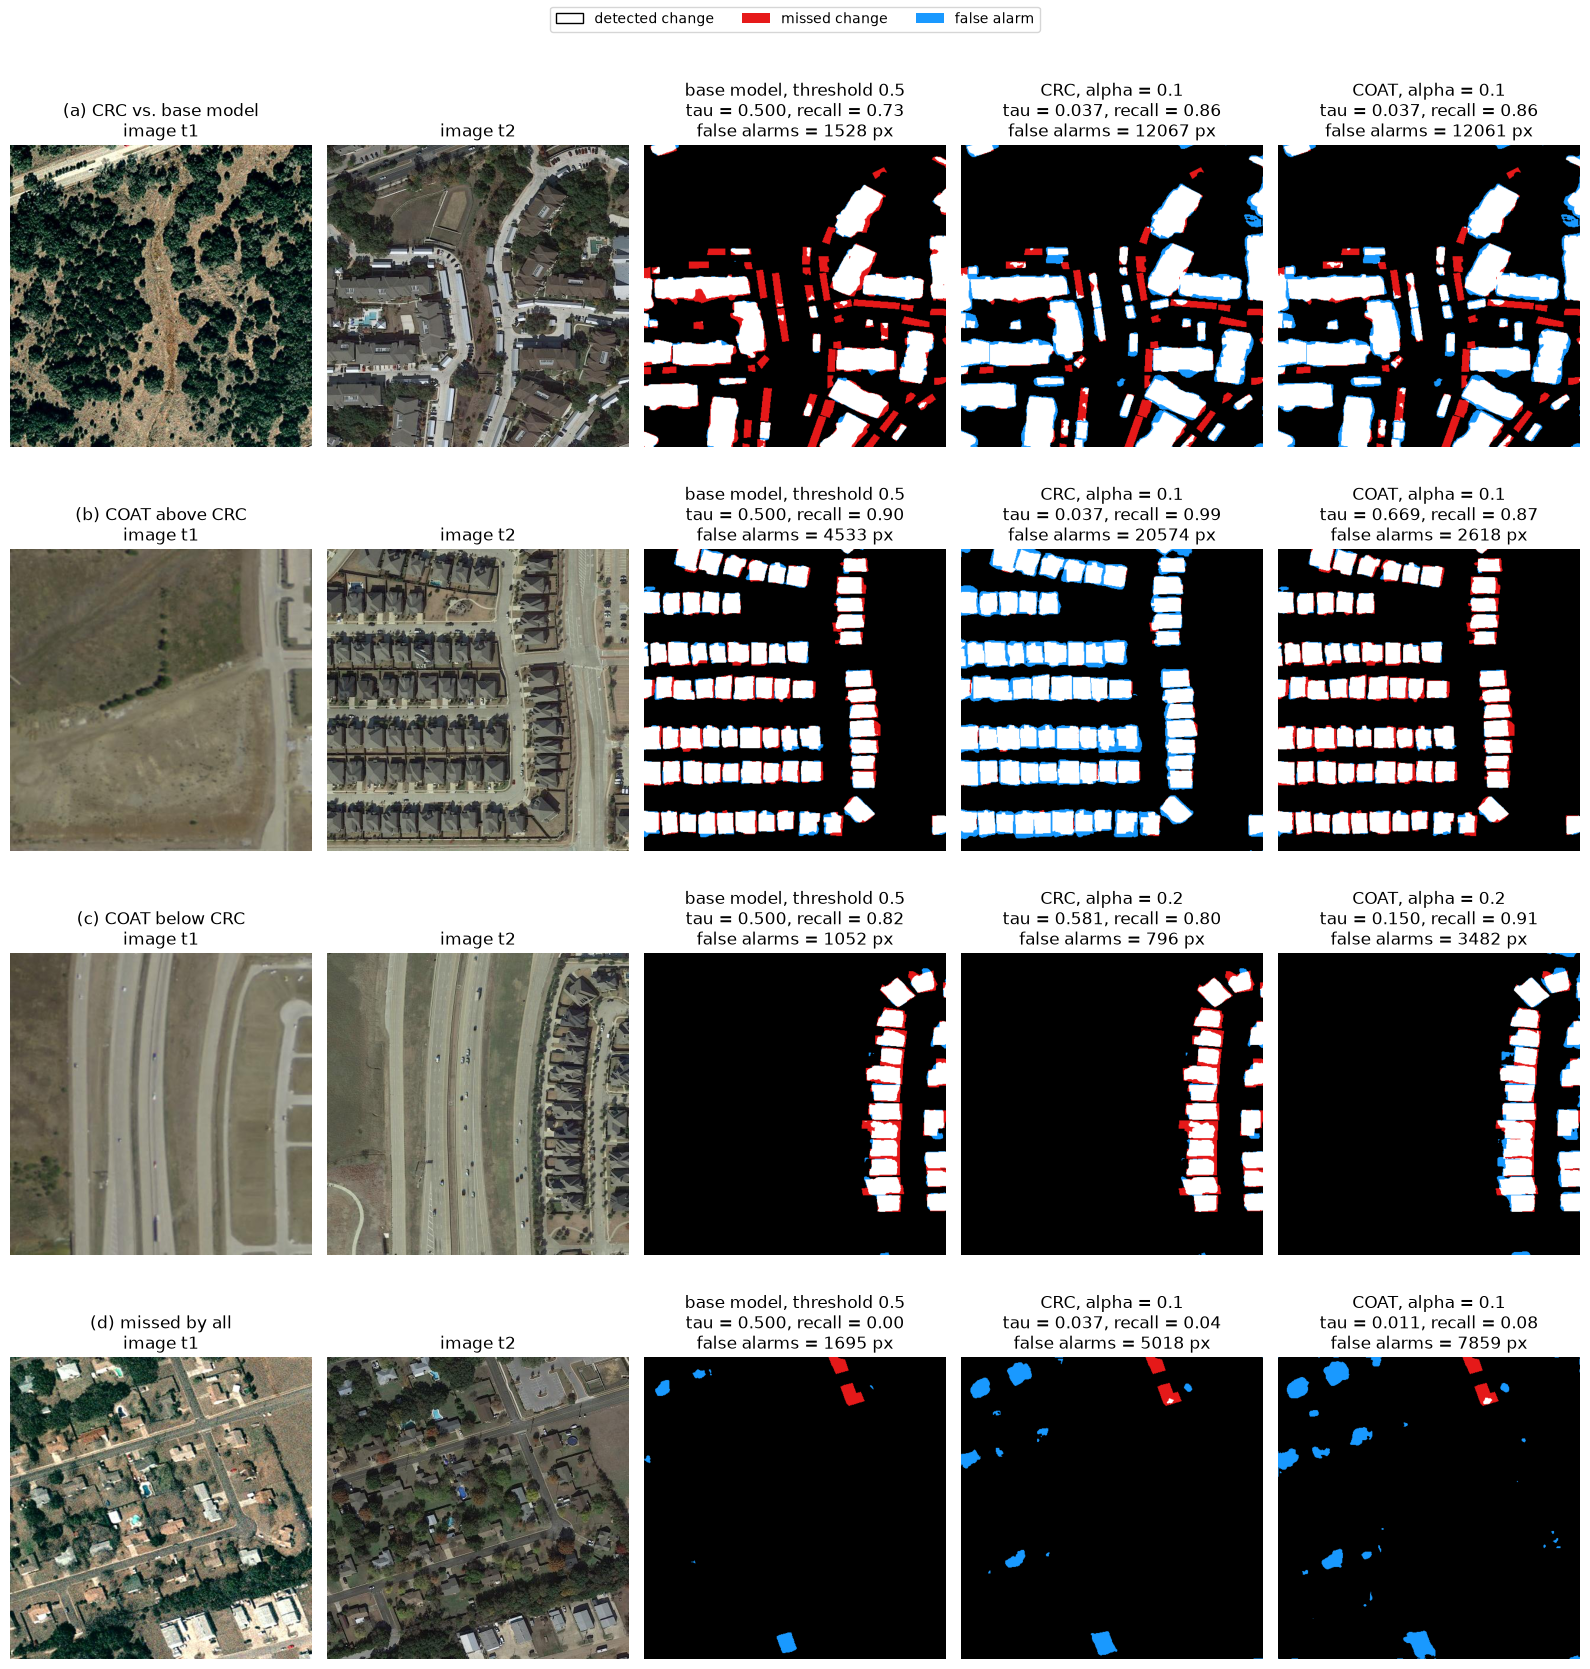

In [15]:
def outcome(alpha: float, name: str) -> tuple[Tensor, Tensor, Tensor]:
    """Per-image recall, false-alarm pixel count and threshold of one rule."""
    tau = torch.as_tensor(rules[(name, alpha)], dtype=test_prob.dtype)
    tau = tau.expand(len(test_prob))
    pred = test_prob >= tau.view(-1, 1, 1, 1)
    return (
        recall(test_prob, test_target, tau),
        (pred & ~test_target).flatten(1).sum(1),
        tau,
    )


def error_map(prob: Tensor, target: Tensor, tau: Tensor) -> Tensor:
    """Color detected change white, missed change red and false alarms blue."""
    pred = prob >= tau
    image = torch.zeros(*prob.shape, 3)
    image[pred & target] = torch.tensor([1.0, 1.0, 1.0])
    image[~pred & target] = torch.tensor([0.9, 0.1, 0.1])
    image[pred & ~target] = torch.tensor([0.1, 0.6, 1.0])
    return image


out = {
    (name, alpha): outcome(alpha, name)
    for alpha in ALPHAS
    for name in ["base model", "CRC", "COAT"]
}
for alpha in ALPHAS:
    r_crc, r_coat, target = out[("CRC", alpha)][0], out[("COAT", alpha)][0], 1 - alpha
    only_coat = int((changed & (r_crc < target) & (r_coat >= target)).sum())
    only_crc = int((changed & (r_crc >= target) & (r_coat < target)).sum())
    print(
        f"alpha = {alpha}: only COAT reaches {target:.1f} on {only_coat} crops, "
        f"only CRC on {only_crc} crops"
    )

size = test_target.flatten(1).sum(1).float()


def pick(score: Tensor, mask: Tensor = changed) -> int:
    """Index of the highest score among the crops in mask."""
    return int(torch.where(mask, score, torch.tensor(float("-inf"))).argmax())


r05, r_crc1, r_crc2 = (
    out[key][0] for key in [("base model", 0.1), ("CRC", 0.1), ("CRC", 0.2)]
)
examples = [
    ("(a) CRC vs. base model", 0.1, pick((r_crc1 - r05) * size)),
    ("(b) COAT above CRC", 0.1, pick(out[("COAT", 0.1)][2] - out[("CRC", 0.1)][2])),
    (
        "(c) COAT below CRC",
        0.2,
        pick((out[("COAT", 0.2)][0] - r_crc2) * size, r_crc2 < 0.8),
    ),
    ("(d) missed by all", 0.1, pick(size, changed & (r_crc1 < 0.1))),
]
test_pairs = ChangePairs(splits["Dtest (evaluation)"])
fig, axes = plt.subplots(len(examples), 5, figsize=(16, 4.3 * len(examples)))
for row, (caption, alpha, index) in zip(axes, examples, strict=True):
    image, _ = test_pairs.raw(index)
    row[0].imshow(image[:3].permute(1, 2, 0))
    row[0].set_title(f"{caption}\nimage t1")
    row[1].imshow(image[3:].permute(1, 2, 0))
    row[1].set_title("image t2")
    for ax, name in zip(row[2:], ["base model", "CRC", "COAT"], strict=True):
        r, fp, tau = (value[index] for value in out[(name, alpha)])
        ax.imshow(error_map(test_prob[index, 0], test_target[index, 0], tau))
        ax.set_title(
            f"{panel_title(name, alpha)}\n"
            f"tau = {tau:.3f}, recall = {r:.2f}\nfalse alarms = {int(fp)} px"
        )
    for ax in row:
        ax.axis("off")
fig.legend(
    handles=[
        Patch(facecolor="white", edgecolor="black", label="detected change"),
        Patch(facecolor=(0.9, 0.1, 0.1), label="missed change"),
        Patch(facecolor=(0.1, 0.6, 1.0), label="false alarm"),
    ],
    loc="upper center",
    ncol=3,
)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

In row (a), the base model with threshold 0.5 detects 73% of the changed pixels, and most of the missed pixels (red)
belong to narrow buildings and building edges. The CRC threshold of 0.037 raises the recall to
0.86, while the number of false-alarm pixels rises from 1,528 to 12,067, mostly along the edges of
detected buildings. COAT predicts the same threshold of 0.037 for this crop. Row (b) shows dense
new construction, where the base model already reaches a recall of 0.90. Here the global CRC
threshold raises the recall to 0.99 and the false alarms from 4,533 to 20,574 pixels. In contrast,
COAT predicts a threshold of 0.669 for this crop, which gives a recall of 0.87 with 2,618
false-alarm pixels. Row (c) shows the opposite adjustment at $\alpha = 0.2$: the global CRC
threshold of 0.581 gives a recall of 0.795, just below the target of 0.8, while COAT lowers the
threshold to 0.150 and reaches a recall of 0.91 with 3,482 instead of 796 false-alarm pixels.
Row (d) shows a crop for which no threshold is adequate. The base model assigns probabilities
below 0.011 to 92% of the changed pixels, so even the COAT threshold detects only 8% of them and
adds 7,859 false-alarm pixels elsewhere in the crop.

These per-crop adjustments work in both directions. For $\alpha = 0.1$, COAT reaches the target
recall on 3 crops on which CRC does not, and CRC reaches it on 12 crops on which COAT does not;
for $\alpha = 0.2$ these counts are 12 and 23. Therefore, the adjustments do not reduce the
coverage gap on this test set, as the table above showed. The difference between the methods
lies in where the false alarms are placed: the single CRC threshold adds false alarms on every
crop, while COAT adds fewer on crops with dense change, as in row (b), and more on crops for
which the global threshold is too high, as in row (c).

## Results over five calibration draws

The results above come from one division of the official test split into calibration and test
images. The table below repeats the calibration and evaluation for five divisions, where draw 0
is the one shown above, and each draw uses threshold networks trained with a different random
seed on the same $D_2$. The rows marked "before calibration" use the network thresholds with
$t' = 0$.

In [16]:
series = pd.read_csv(fetch("series_summary.csv"))
labels = {
    "crc_matched_calibration": "CRC",
    "at_uncalibrated": "AT before calibration",
    "at": "AT",
    "coat_uncalibrated": "COAT before calibration",
    "coat": "COAT",
}
columns = {
    "coverage": "coverage",
    "coverage_nonempty": "coverage (crops with change)",
    "coverage_gap": "coverage gap",
    "f1": "F1",
    "iou": "IoU",
    "foreground_fraction": "predicted foreground",
    "tau_clipped_zero_fraction": "tau = 0",
}
series = series[series["method"].isin(labels)]
table = pd.DataFrame(
    {
        label: series[f"{key}_mean"].map("{:.3f}".format)
        + " ± "
        + series[f"{key}_std"].map("{:.3f}".format)
        for key, label in columns.items()
    }
)
table.index = pd.MultiIndex.from_arrays(
    [series["alpha"], series["method"].map(labels)], names=["alpha", "method"]
)
table.sort_index(level=0, sort_remaining=False)

coverage coverage (crops with change)  \
alpha method                                                                
0.1   AT                       0.899 ± 0.016                0.853 ± 0.026   
      AT before calibration    0.749 ± 0.013                0.634 ± 0.023   
      COAT                     0.902 ± 0.013                0.857 ± 0.018   
      COAT before calibration  0.904 ± 0.028                0.860 ± 0.043   
      CRC                      0.905 ± 0.016                0.861 ± 0.022   
0.2   AT                       0.786 ± 0.018                0.687 ± 0.027   
      AT before calibration    0.700 ± 0.013                0.562 ± 0.020   
      COAT                     0.788 ± 0.010                0.690 ± 0.018   
      COAT before calibration  0.832 ± 0.015                0.754 ± 0.020   
      CRC                      0.785 ± 0.017                0.686 ± 0.023   

                                coverage gap             F1            IoU  \
alpha method                                                                 
0.1   AT                       0.140 ± 0.010  0.237 ± 0.043  0.135 ± 0.028   
      AT before calibration    0.219 ± 0.013  0.820 ± 0.015  0.694 ± 0.021   
      COAT                     0.134 ± 0.009  0.558 ± 0.243  0.417 ± 0.225   
      COAT before calibration  0.132 ± 0.016  0.629 ± 0.173  0.476 ± 0.175   
      CRC                      0.142 ± 0.009  0.753 ± 0.020  0.605 ± 0.026   
0.2   AT                       0.209 ± 0.005  0.823 ± 0.017  0.699 ± 0.025   
      AT before calibration    0.244 ± 0.011  0.768 ± 0.012  0.623 ± 0.016   
      COAT                     0.212 ± 0.009  0.806 ± 0.021  0.676 ± 0.030   
      COAT before calibration  0.198 ± 0.004  0.656 ± 0.125  0.498 ± 0.141   
      CRC                      0.212 ± 0.002  0.847 ± 0.008  0.735 ± 0.012   

                              predicted foreground        tau = 0  
alpha method                                                       
0.1   AT                             0.281 ± 0.054  0.244 ± 0.056  
      AT before calibration          0.034 ± 0.002  0.000 ± 0.000  
      COAT                           0.121 ± 0.083  0.066 ± 0.093  
      COAT before calibration        0.088 ± 0.051  0.000 ± 0.000  
      CRC                            0.061 ± 0.005  0.000 ± 0.000  
0.2   AT                             0.039 ± 0.004  0.002 ± 0.002  
      AT before calibration          0.029 ± 0.001  0.000 ± 0.000  
      COAT                           0.035 ± 0.002  0.000 ± 0.000  
      COAT before calibration        0.062 ± 0.019  0.000 ± 0.000  
      CRC                            0.038 ± 0.002  0.000 ± 0.000

The coverage of the three calibrated methods is within one standard deviation of $1-\alpha$,
between 0.899 and 0.905 for $\alpha = 0.1$ and between 0.785 and 0.788 for $\alpha = 0.2$. The
coverage gaps of CRC, AT and COAT differ by less than their standard deviations at both levels.
Therefore, on this base model and data we do not observe a smaller coverage gap for the
per-image methods than for the global CRC threshold. However, the methods differ in the size of
their masks at $\alpha = 0.1$. CRC reaches F1 0.753, while AT predicts 28% of all pixels as
change and reaches F1 0.237. The COAT results vary strongly between draws: in two of the five
draws, its network set the threshold of 13% and 20% of the test images to zero, which gives F1
0.34 and 0.25, while the other three draws reach F1 between 0.71 and 0.78. The calibration
shifts of COAT are close to zero in all five draws, so this variation comes from training the
threshold network and not from the calibration.

Before calibration, AT reaches a coverage of only 0.749 for $\alpha = 0.1$. We conjecture that
the oracle thresholds learned on $D_2$ are too high for the test images, because the base model
is more accurate on $D_2$ (F1 0.920 at the final epoch) than on $D_\mathrm{test}$ (F1 0.839 at
threshold 0.5). COAT reaches 0.904 before calibration, with a standard deviation of 0.028 across
draws. For both networks, the finite-sample statement from the first section applies only after
the calibration step.